# Linear Regression with Gradient Descent
### Predicting House Cost using Bedrooms and Area

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Generate synthetic data
n_samples = 50

# Features: Bedrooms and Area
bedrooms = np.random.uniform(1, 5, n_samples)  # 1 to 5 bedrooms
area = np.random.uniform(1000, 5000, n_samples)  # 1000 to 5000 sq ft

# Label: Cost of house (with relationship and random noise)
cost = 50000 + 100000 * bedrooms + 10 * area + np.random.normal(0, 50000, n_samples)

print(f"Data Shape: {n_samples} samples")
print(f"Features Shape: ({n_samples}, 2)")
print(f"First 5 samples:")
print(f"Bedrooms: {bedrooms[:5]}")
print(f"Area: {area[:5]}")
print(f"Cost: {cost[:5]}")

Data Shape: 50 samples
Features Shape: (50, 2)
First 5 samples:
Bedrooms: [2.49816048 4.80285723 3.92797577 3.39463394 1.62407456]
Area: [4878.33851106 4100.53129344 4757.99576626 4579.30940171 3391.59991524]
Cost: [352951.78606144 556340.66797512 494965.5732139  335878.04196588
 235339.86093754]


In [4]:
# Prepare data: X (features) and y (labels)
X = np.column_stack([bedrooms, area])
y = cost

# Normalize features for better gradient descent
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_normalized = (X - X_mean) / X_std

# Add intercept term (bias)
X_with_intercept = np.column_stack([np.ones(n_samples), X_normalized])

# Initialize parameters
params = np.zeros(3)  # for intercept, bedroom coefficient, area coefficient

# Gradient Descent parameters
learning_rate = 0.01
iterations = 100
m = n_samples

# Store cost history
cost_history = []

print("Starting Gradient Descent Training...\n")

Starting Gradient Descent Training...



In [11]:
# Gradient Descent Loop
for i in range(iterations):
    # Predictions
    predictions = X_with_intercept.dot(params)
    
    # Calculate error
    error = predictions - y
    
    # Calculate Mean Squared Error (MSE)
    mse = np.sum(error**2) / (2 * m)
    cost_history.append(mse)
    
    # Calculate gradients
    gradients = X_with_intercept.T.dot(error) / m
    
    # Update parameters
    params = params - learning_rate * gradients
    
    if (i + 1) % 20 == 0:
        print(f"Iteration {i + 1}: Cost = {mse:.2f}")

print(f"\nTraining Complete!")
print(f"Final Cost: {cost_history[-1]:.2f}")

Iteration 20: Cost = 1746992829.27
Iteration 40: Cost = 1467272632.91
Iteration 60: Cost = 1280156167.43
Iteration 80: Cost = 1154981042.64
Iteration 100: Cost = 1071239316.91

Training Complete!
Final Cost: 1071239316.91


In [ ]:
# Make predictions
y_pred = X_with_intercept.dot(params)

# Calculate R² score
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2_score = 1 - (ss_res / ss_tot)

print(f"\nModel Evaluation:")
print(f"R² Score: {r2_score:.4f}")
print(f"\nLearned Parameters (unscaled):")
print(f"Intercept: {params[0]:.2f}")
print(f"Bedroom Coefficient: {params[1]:.2f}")
print(f"Area Coefficient: {params[2]:.2f}")


Model Evaluation:
R² Score: -0.8273

Learned Parameters (unscaled):
Intercept: 227661.67
Bedroom Coefficient: 60622.33
Area Coefficient: 8272.95


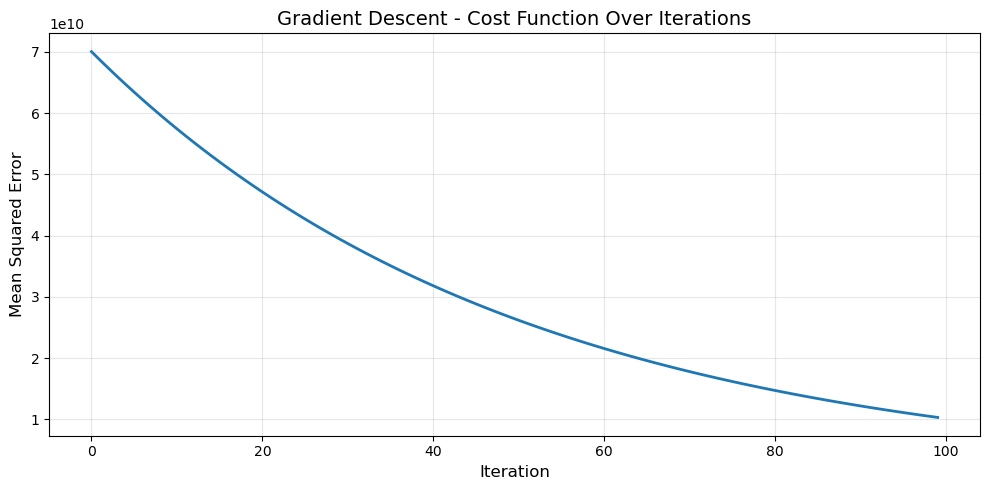

Cost function is decreasing - Model is learning!


In [7]:
# Visualization 1: Cost History (showing convergence)
plt.figure(figsize=(10, 5))
plt.plot(cost_history, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Gradient Descent - Cost Function Over Iterations', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cost function is decreasing - Model is learning!")

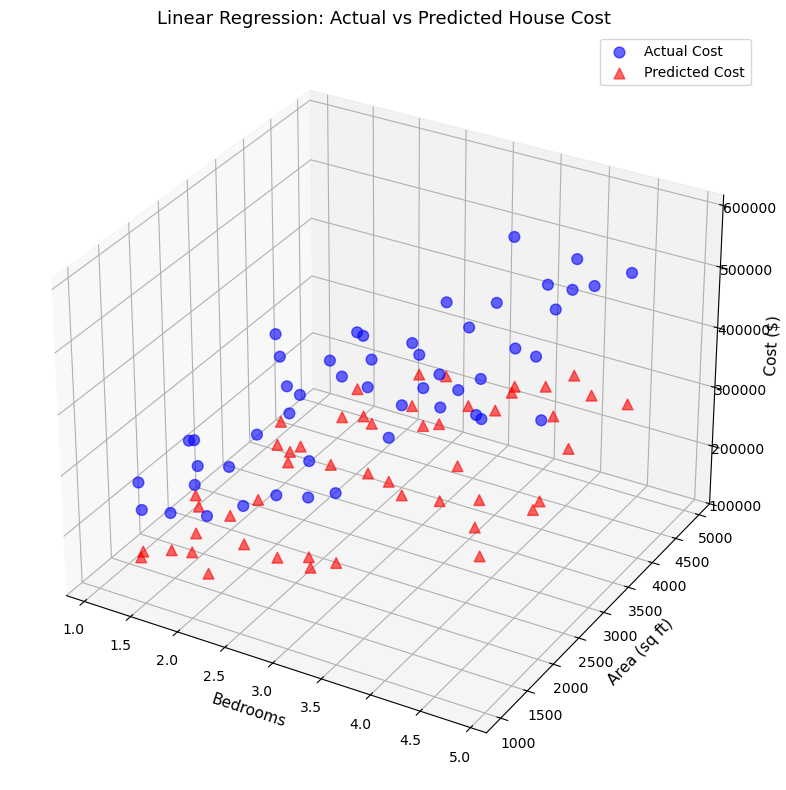

Blue dots = Actual cost, Red triangles = Predicted cost


In [8]:
# Visualization 2: 3D Scatter Plot (Actual vs Predicted)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data
ax.scatter(bedrooms, area, y, color='blue', label='Actual Cost', s=60, alpha=0.6)

# Plot predicted data
ax.scatter(bedrooms, area, y_pred, color='red', label='Predicted Cost', s=60, alpha=0.6, marker='^')

ax.set_xlabel('Bedrooms', fontsize=11)
ax.set_ylabel('Area (sq ft)', fontsize=11)
ax.set_zlabel('Cost ($)', fontsize=11)
ax.set_title('Linear Regression: Actual vs Predicted House Cost', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Blue dots = Actual cost, Red triangles = Predicted cost")

In [ ]:
# Test: Predict cost for a new house
new_bedrooms = 3
new_area = 2500

# Normalize the new data
new_data = np.array([new_bedrooms, new_area])
new_data_normalized = (new_data - X_mean) / X_std

# Add intercept
new_data_with_intercept = np.insert(new_data_normalized, 0, 1)

# Make prediction
predicted_cost = new_data_with_intercept.dot(params)

print(f"Test Prediction:")
print(f"House with {new_bedrooms} bedrooms and {new_area} sq ft")
print(f"Predicted Cost: ${predicted_cost:,.2f}")

Test Prediction:
House with 3 bedrooms and 2500 sq ft
Predicted Cost: $235,871.86
